In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

from base_func_H_accu import base_func_H

In [2]:
K = 6
T = 50000
M = 5
rng = np.random.default_rng()
mu_max = 1
mu_min = 0.8
mu = np.concatenate(([mu_max], mu_min * np.ones(K - 1)))
mu = np.concatenate(([1], 0.8* np.ones(K - 1)))
print(mu)

[1.  0.8 0.8 0.8 0.8 0.8]


In [4]:
eps_list = [1.1, 1.7]
trace_mean_by_eps = {}
time_axis = np.arange(T + 1, dtype=int)
regret_tot = {}
active = {}

In [5]:
for eps in [1.1]:
    regret_d, _, regret_trace, time_trace, active_d, _ = base_func_H(
        mu, K, T, M, "instance-dependent", eps=eps, rng=rng, return_trace=True
    )
    full_trace = np.zeros(T + 1, dtype=float)
    full_trace[time_trace] = regret_trace
    observed = np.zeros(T + 1, dtype=bool)
    observed[time_trace] = True
    full_trace = np.maximum.accumulate(np.where(observed, full_trace, -np.inf))
    full_trace[~np.isfinite(full_trace)] = 0.0
    trace_mean_by_eps[eps] = full_trace
    regret_tot[eps] = regret_d
    active[eps] = active_d

In [6]:
print(regret_tot)
print(active)

{1.1: 9996.400000001304}
{1.1: array([[1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 0, 0],
       [0, 0, 1, 1, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0, 0]])}


In [7]:
for eps in [1.7]:
    regret_d, _, regret_trace, time_trace, active_d, _ = base_func_H(
        mu, K, T, M, "instance-dependent", eps=eps, rng=rng, return_trace=True
    )
    full_trace = np.zeros(T + 1, dtype=float)
    full_trace[time_trace] = regret_trace
    observed = np.zeros(T + 1, dtype=bool)
    observed[time_trace] = True
    full_trace = np.maximum.accumulate(np.where(observed, full_trace, -np.inf))
    full_trace[~np.isfinite(full_trace)] = 0.0
    trace_mean_by_eps[eps] = full_trace
    regret_tot[eps] = regret_d
    active[eps] = active_d

In [8]:
print(regret_tot)
print(active)

{1.1: 9996.400000001304, 1.7: 9997.600000001308}
{1.1: array([[1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 0, 0],
       [0, 0, 1, 1, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0, 0]]), 1.7: array([[1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0]])}


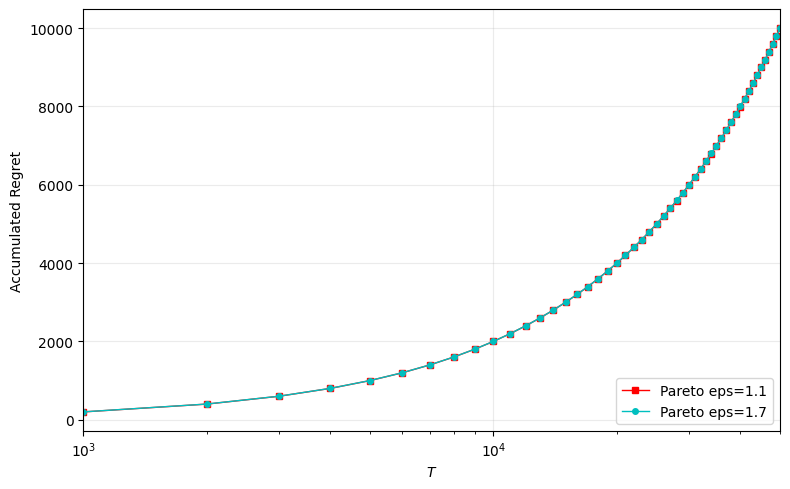

In [9]:
plot_step = int(os.environ.get("BB_PLOT_STEP",1000))
plot_idx = np.arange(0, T + 1, max(plot_step, 1), dtype=int)
if plot_idx[-1] != T:
    plot_idx = np.append(plot_idx, T)

plt.figure(figsize=(8, 5))
plt.plot(
    time_axis[plot_idx],
    trace_mean_by_eps[1.1][plot_idx],
    "r-s",
    markerfacecolor="r",
    linewidth=1,
    markersize=4,
    label="Pareto eps=1.1",
)
plt.plot(
    time_axis[plot_idx],
    trace_mean_by_eps[1.7][plot_idx],
    "c-o",
    markerfacecolor="c",
    linewidth=1,
    markersize=4,
    label="Pareto eps=1.7",
)
plt.xlim([0, T])
plt.xlabel("t")
plt.ylabel("Accumulated Regret")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("plot_T_addnew_accu.png", dpi=200)
plt.show()

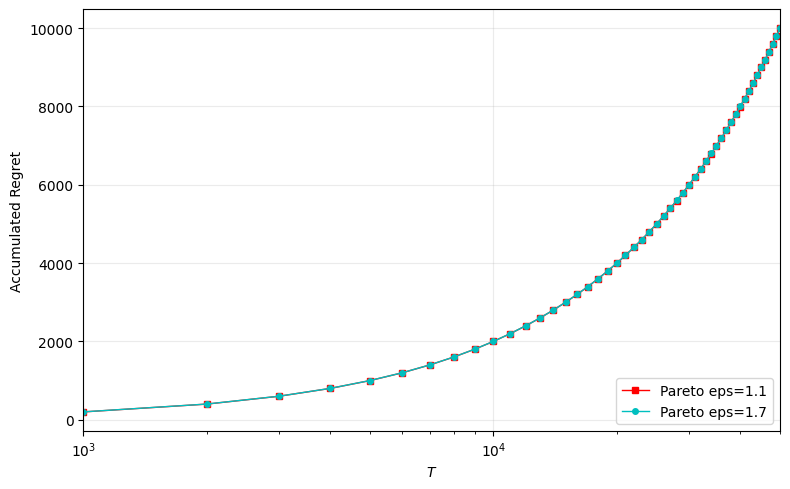

In [10]:
# New cell: log-scale x-axis plot (keep original cell unchanged)
plot_step = int(os.environ.get("BB_PLOT_STEP", 1000))
plot_idx = np.arange(0, T + 1, max(plot_step, 1), dtype=int)
if plot_idx[-1] != T:
    plot_idx = np.append(plot_idx, T)

# semilogx cannot take x=0
plot_idx_pos = plot_idx[plot_idx > 0]

plt.figure(figsize=(8, 5))
plt.semilogx(
    time_axis[plot_idx_pos],
    trace_mean_by_eps[1.1][plot_idx_pos],
    "r-s",
    markerfacecolor="r",
    linewidth=1,
    markersize=4,
    label="Pareto eps=1.1",
)
plt.semilogx(
    time_axis[plot_idx_pos],
    trace_mean_by_eps[1.7][plot_idx_pos],
    "c-o",
    markerfacecolor="c",
    linewidth=1,
    markersize=4,
    label="Pareto eps=1.7",
)
plt.xlim([plot_idx_pos[0], T])
plt.xlabel("$T$")
plt.ylabel("Accumulated Regret")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("plot_T_addnew_accu_logx.png", dpi=200)
plt.show()